# Notebook 05 — Visualizations

Two charts, both built directly from `04_comparison_output.json` — no new computation, no API calls. Only two, deliberately: these are the only two results in the project that are genuinely trends over time with a built-in comparison. Everything else (Facility A's clean run, the confidence review queue) is better stated as a sentence than a chart.

**Output:** `charts/facility_b_divergence.png`, `charts/facility_c_amendment_timeline.png`

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RECORDS_DIR = Path("../records")
CHARTS_DIR = Path("../charts")
CHARTS_DIR.mkdir(exist_ok=True)

with open(RECORDS_DIR / "04_comparison_output.json") as f:
    comparison_data = json.load(f)

print("Loaded comparison output.")
print("Facility B periods:", len(comparison_data["Facility B"]["delinquency_ratio_tests"]))
print("Facility C periods:", len(comparison_data["Facility C"]["leverage_ratio_tests"]))

Matplotlib is building the font cache; this may take a moment.


Loaded comparison output.
Facility B periods: 6
Facility C periods: 8


## Chart 1 — Facility B: Same Data, Two Definitions

Facility B's own contractual definition (90+ days delinquent ÷ fixed original pool balance) stays well under its 4.00% trigger throughout. The same raw delinquency data, run through Facility A's definition instead (60+ days ÷ current, shrinking balance), climbs steeply and crosses Facility A's 5.00% trigger by the final period — the exact mistake someone would make reusing a familiar definition without checking the governing terms.

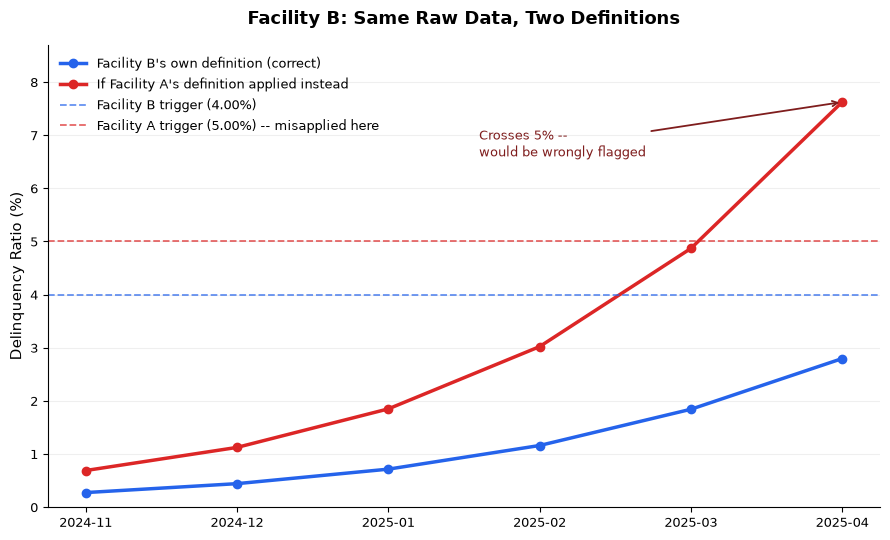


Saved to ../charts/facility_b_divergence.png


In [3]:
b_tests = comparison_data["Facility B"]["delinquency_ratio_tests"]
periods_b = [r["period"] for r in b_tests]
correct_ratio = [r["correct_ratio_pct"] for r in b_tests]
wrong_ratio = [r["if_wrongly_using_facility_a_definition_pct"] for r in b_tests]

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(periods_b, correct_ratio, marker='o', linewidth=2.5, color='#2563eb',
        label="Facility B's own definition (correct)")
ax.plot(periods_b, wrong_ratio, marker='o', linewidth=2.5, color='#dc2626',
        label="If Facility A's definition applied instead")

ax.axhline(4.00, color='#2563eb', linestyle='--', linewidth=1.3, alpha=0.7,
           label="Facility B trigger (4.00%)")
ax.axhline(5.00, color='#dc2626', linestyle='--', linewidth=1.3, alpha=0.7,
           label="Facility A trigger (5.00%) -- misapplied here")

ax.annotate("Crosses 5% --\nwould be wrongly flagged",
            xy=(5, wrong_ratio[-1]), xytext=(2.6, 6.6),
            fontsize=9.5, color='#7f1d1d',
            arrowprops=dict(arrowstyle='->', color='#7f1d1d', lw=1.3))

ax.set_ylabel("Delinquency Ratio (%)", fontsize=10.5)
ax.set_title("Facility B: Same Raw Data, Two Definitions", fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left', frameon=False, fontsize=9.5)
ax.set_ylim(0, 8.7)
ax.grid(axis='y', alpha=0.2)
ax.tick_params(labelsize=9.5)

plt.tight_layout()
plt.savefig(CHARTS_DIR / "facility_b_divergence.png", dpi=150)
plt.show()

print(f"\nSaved to {CHARTS_DIR / 'facility_b_divergence.png'}")

## Chart 2 — Facility C: Amendment Resolution Over Time

The leverage ratio's actual trajectory against the correctly-resolved governing threshold, which steps from 3.50x to 4.00x at the amendment's effective date. The shaded region marks where a naive resolver — one that only ever read the original agreement — would have wrongly concluded a breach on two periods that are, under the correctly resolved threshold, genuinely compliant.

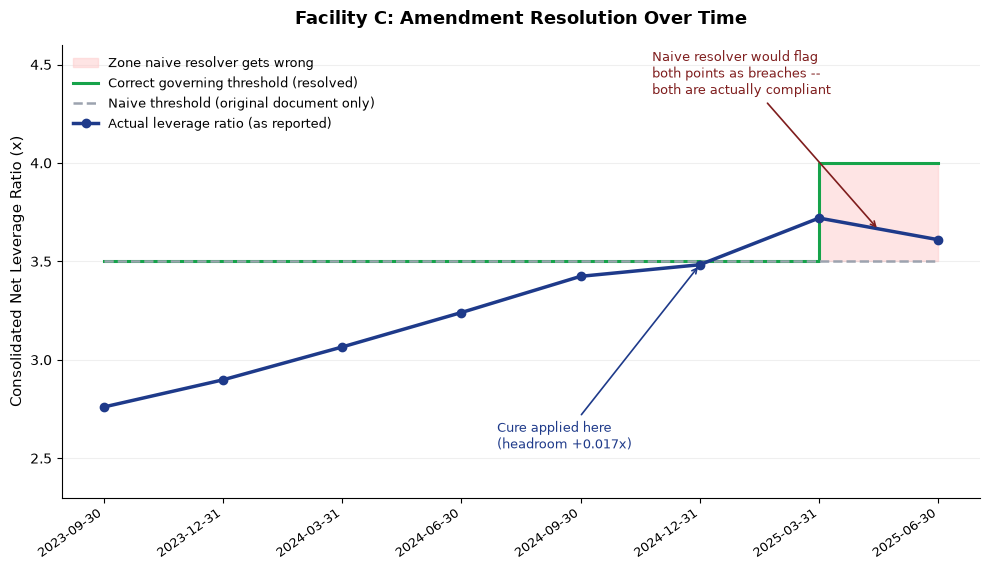


Saved to ../charts/facility_c_amendment_timeline.png


In [4]:
c_tests = comparison_data["Facility C"]["leverage_ratio_tests"]
periods_c = [r["test_period_end"] for r in c_tests]
adjusted_ratio = [r["adjusted_ratio"] for r in c_tests]
correct_threshold = [r["governing_threshold"] for r in c_tests]
naive_threshold = [3.50] * len(c_tests)

x = range(len(periods_c))

fig, ax = plt.subplots(figsize=(10, 5.8))

ax.fill_between(x, naive_threshold, correct_threshold,
                 where=[c > n for c, n in zip(correct_threshold, naive_threshold)],
                 color='#fecaca', alpha=0.5, step='post', label="Zone naive resolver gets wrong")

ax.step(x, correct_threshold, where='post', color='#16a34a', linewidth=2.2,
        label="Correct governing threshold (resolved)")
ax.step(x, naive_threshold, where='post', color='#9ca3af', linewidth=1.8, linestyle='--',
        label="Naive threshold (original document only)")

ax.plot(x, adjusted_ratio, marker='o', linewidth=2.5, color='#1e3a8a',
        label="Actual leverage ratio (as reported)")

cure_idx = periods_c.index("2024-12-31")
ax.annotate("Cure applied here\n(headroom +0.017x)",
            xy=(cure_idx, adjusted_ratio[cure_idx]), xytext=(3.3, 2.55),
            fontsize=9, color='#1e3a8a',
            arrowprops=dict(arrowstyle='->', color='#1e3a8a', lw=1.2))

ax.annotate("Naive resolver would flag\nboth points as breaches --\nboth are actually compliant",
            xy=(6.5, 3.66), xytext=(4.6, 4.35),
            fontsize=9, color='#7f1d1d',
            arrowprops=dict(arrowstyle='->', color='#7f1d1d', lw=1.2))

ax.set_xticks(list(x))
ax.set_xticklabels(periods_c, rotation=35, ha='right', fontsize=9)
ax.set_ylabel("Consolidated Net Leverage Ratio (x)", fontsize=10.5)
ax.set_title("Facility C: Amendment Resolution Over Time", fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.set_ylim(2.3, 4.6)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig(CHARTS_DIR / "facility_c_amendment_timeline.png", dpi=150)
plt.show()

print(f"\nSaved to {CHARTS_DIR / 'facility_c_amendment_timeline.png'}")

## Summary

Two charts, both saved to `charts/`, both built directly from Notebook 04's verified output:

- `facility_b_divergence.png` — the definitional-inconsistency proof: same raw data, two definitions, two different risk conclusions.
- `facility_c_amendment_timeline.png` — the amendment-resolution proof: correct threshold resolution against what a naive system would have wrongly flagged.

Both are ready to drop directly into the technical deck.